# Tutorial: Quantum Control Optimisation with Bayesian Optimisation (BO)  
## Implementing BO for GHZ State Preparation


This hands-on guide demonstrates implementation of BO for optimising quantum state preparation fidelity. We focus on creating a 3-qubit GHZ state:

$$\frac{|000\rangle +|111\rangle}{\sqrt{2}}$$

using two approaches:  
1. A **single surrogate model** directly estimating the fidelity. From now on we will refer to this approach as *GP Fidelity*
2. **Multiple surrogate models** estimating different observables, which are then used to reconstruct the fidelity. From now on we will refer to this approach as *GPs Observables*  


First we import the required libraries. Where we can highlight create_parametrized_circuit, function that allow us create a quantum circuit and that can be modified easily and the optimiser: BayesianOptimiserFidelity and BayesianOptimiserObservables.


**Key Implementation Tools:**
- `create_parametrized_circuit(num_qubits, thetas, initial_state, entanglement='CX')`:  
  Constructs tunable quantum circuits with:
  - Parametrised rotation gates (X, Y, Z)
  - Entangling layers
  - Customisable ansatz architecture

- **BO Optimisers**:
Enable the creation of BO optimisers with tunable hyperparameters.

Note: The hyperparameters that you will find in this notebook have not been optimised.

In [ ]:
import numpy as np
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(os.path.join(parent_dir, 'src/utils/'))
sys.path.append(os.path.join(parent_dir, 'src/bo/'))
import json
from functions import CustomEncoder
from circuit_utils import create_parametrized_circuit
from optimisation_bo import BayesianOptimiserFidelity, BayesianOptimiserObservables

First, we define the number of qubits of our problem, the number of angles, that in our case there are two parameters per qubits, the target and initial state.

In [2]:

# Define the quantum system parameters, including qubit count and parameter bounds.
num_qubits = 3
n_thetas = num_qubits * 2  # Each qubit has two tunable parameters
param_bounds = [[0, 2 * np.pi] for _ in range(n_thetas)]

target_state = np.array([1, 0, 0, 0, 0, 0, 0, 1]) / np.sqrt(2)
initial_state = np.array([1, 0, 0, 0, 0, 0, 0, 0])

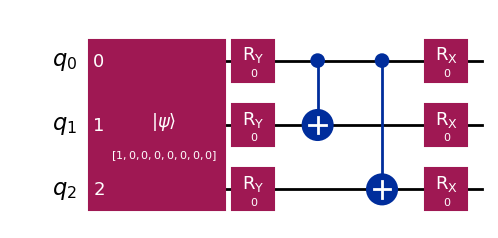

In [3]:
qc = create_parametrized_circuit(num_qubits, np.zeros(n_thetas)[np.newaxis,:], initial_state)
qc.draw('mpl')


## Training and Evaluating the First Approach (GP Fidelity) 

In this section, we train and evaluate the first approach, where a single surrogate model is used to estimate fidelity. We begin by defining the necessary hyperparameters and specifying the number of runs for the same architecture to ensure consistency in our results.  


In [ ]:
hyperparams = {
    'num_iters': 50, #Number of iteration = Number of angles sets to test
    'training_iter': 10,
    'learning_rate': 0.1,
    'initial_lengthscale': 0.9,
    'initial_noise': 1e-8,
    'initial_output_scale': 1,
    'verbose': 0,
    'beta': 1,
    'raw_samples':1000,
    'num_restarts':5,
    'scaler_target':None
    }  

n_run = 2

metrics = {'history_best_fidelity_runs':[],
           'history_best_thetas_runs':[],
           'best_fidelity_runs':[],
           'best_thetas_runs': []}
for iter_run in range(n_run):
    print('run ', iter_run+1)
        
    # Initialize Bayesian Optimiser
    optimiser = BayesianOptimiserFidelity(
        circuit=create_parametrized_circuit,
        n_thetas=n_thetas,
        initial_state=initial_state,
        target_state=target_state,
        param_bounds=param_bounds,
        num_qubits=num_qubits,
        num_initial_samples=1,
        hyperparams=hyperparams,
        )

    # Run optimisation
    optimal_params, fidelity, info = optimiser.optimise()

    print("Optimal parameters found:", optimal_params)
    print("Optimal fidelity found:", fidelity)

    log_best_thetas = np.array(info['best_log']['thetas'] )
    log_best_fidelity = np.array(info['best_log']['fidelity'] )

    metrics['history_best_thetas_runs'].append(log_best_thetas)
    metrics['history_best_fidelity_runs'].append(log_best_fidelity)
    metrics['best_thetas_runs'].append(optimal_params)
    metrics['best_fidelity_runs'].append(fidelity)

    

run  1
Optimal parameters found: [1.50291653 3.08486073 3.17677206 6.28318531 3.10878924 3.08205233]
Optimal fidelity found: 0.9965846279791319
run  2
Optimal parameters found: [1.65014391 6.28318531 3.0688699  3.10418167 3.18507761 0.        ]
Optimal fidelity found: 0.996316844630209


We can save our results for later analysis

In [5]:

if True:
    name_output_file = "example_results_3ghz_bo_fidelity"
    
    data_plot = {'history_best_fidelity_runs':metrics['history_best_fidelity_runs'],
                'best_thetas_runs': metrics['best_thetas_runs'],
                'best_fidelity_runs':metrics['best_fidelity_runs']} 
    with open("../results/" + name_output_file + ".json", "w") as outfile: 
        json.dump(data_plot, outfile, cls=CustomEncoder)


We plot the results

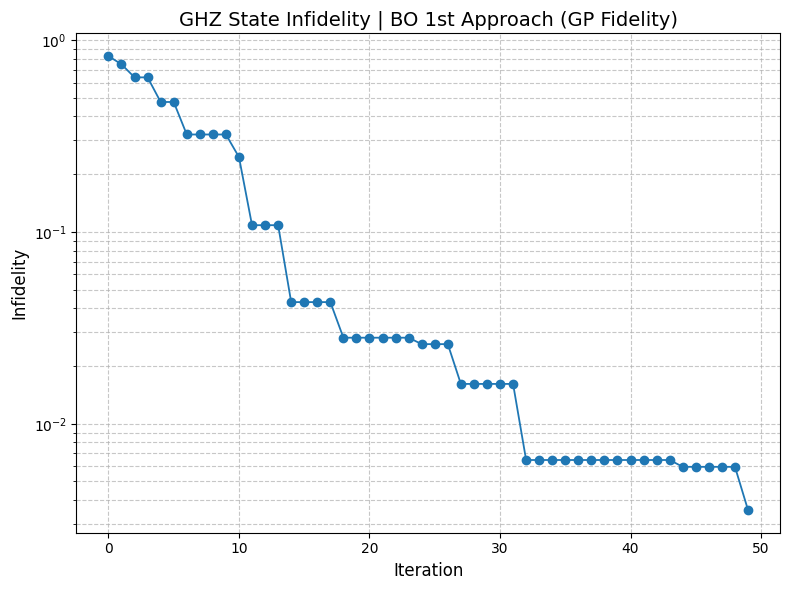

Mean Best Infidelity:  0.0035492636953295964


In [6]:
import matplotlib.pylab as plt

plt.figure(figsize=(8, 6)) 
plt.plot(np.arange(hyperparams['num_iters'],dtype=int),1-np.mean(metrics['history_best_fidelity_runs'],0),
          marker='o', linestyle='-', linewidth=1.3)
plt.ylabel('Infidelity', fontsize=12)
plt.xlabel('Iteration', fontsize=12)
plt.yscale('log')
plt.title('GHZ State Infidelity | BO 1st Approach (GP Fidelity)', fontsize=14)
plt.grid(True, which='both', axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print('Mean Best Infidelity: ', 1-np.mean(metrics['best_fidelity_runs']))

## Training and evaluating the Second Approach (GPs Observables) 

Next, we apply the same process to the second approach, where multiple surrogate models are used to estimate the observables. We begin by defining the necessary hyperparameters and specifying the number of runs for the same architecture to ensure consistency in our results.  

In [ ]:
hyperparams = {
    'num_iters': 50, #Number of iteration = Number of angles sets to test
    'training_iter': 10,
    'learning_rate': 0.1,
    'initial_lengthscale': 0.9,
    'initial_noise': 1e-8,
    'initial_output_scale': 1,
    'verbose': 0,
    'beta': 1,
    'raw_samples':1000,
    'num_restarts':5,
    'scaler_target':None
    }   

n_run = 2

metrics = {'history_best_fidelity_runs':[],
           'history_best_thetas_runs':[],
           'best_fidelity_runs':[],
           'best_thetas_runs': []}

for iter_run in range(n_run):
    print('run ', iter_run+1)
        
    optimiser = BayesianOptimiserObservables(
        circuit=create_parametrized_circuit,
        n_thetas=n_thetas,
        initial_state=initial_state,
        target_state=target_state,
        param_bounds=param_bounds,
        num_qubits=num_qubits,
        num_initial_samples=1, 
        hyperparams=hyperparams
        )

    # Run optimisation
    optimal_params, fidelity, info = optimiser.optimise()

    print("Optimal parameters found:", optimal_params)
    print("Optimal fidelity found:", fidelity)


    log_best_thetas = np.array(info['best_log']['thetas'] )
    log_best_fidelity = np.array(info['best_log']['fidelity'] )

    metrics['history_best_thetas_runs'].append(log_best_thetas)
    metrics['history_best_fidelity_runs'].append(log_best_fidelity)
    metrics['best_thetas_runs'].append(optimal_params)
    metrics['best_fidelity_runs'].append(fidelity)



run  1
Optimal parameters found: [1.57043289 3.14162802 6.28318531 3.14164027 6.28318531 3.14201758]
Optimal fidelity found: 0.9999999209596309
run  2
Optimal parameters found: [1.5709002  6.28318531 6.28318531 6.28318531 0.         6.28318531]
Optimal fidelity found: 0.999999997302569


In [8]:

if True:
    name_output_file = "example_results_3ghz_bo_observables"
    data_plot = {'history_best_fidelity_runs':metrics['history_best_fidelity_runs'],
                'best_thetas_runs': metrics['best_thetas_runs'],
                'best_fidelity_runs':metrics['best_fidelity_runs']} 
    with open("../results/" + name_output_file + ".json", "w") as outfile: 
        json.dump(data_plot, outfile, cls=CustomEncoder)


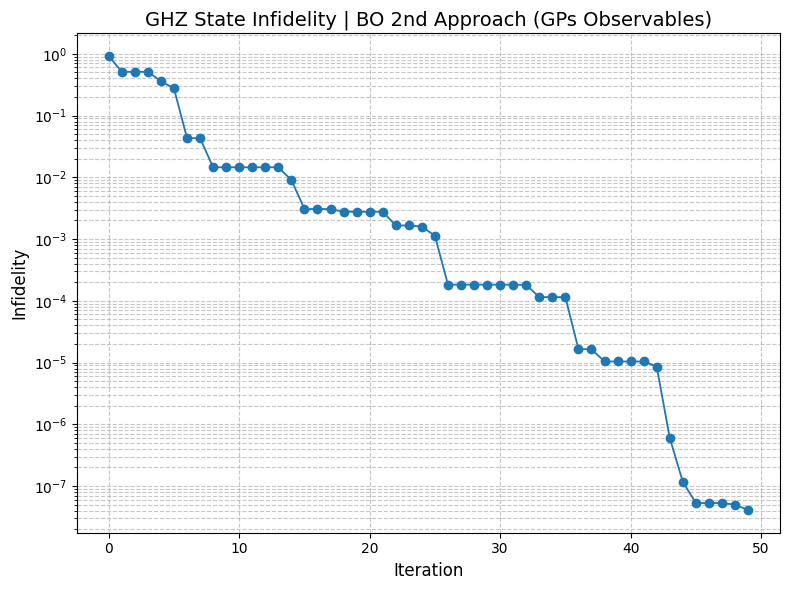

Mean Best Infidelity:  4.086890004195709e-08


In [9]:
plt.figure(figsize=(8, 6)) 
plt.plot(np.arange(hyperparams['num_iters'],dtype=int),1-np.mean(metrics['history_best_fidelity_runs'],0),
          marker='o', linestyle='-', linewidth=1.3)
plt.ylabel('Infidelity', fontsize=12)
plt.xlabel('Iteration', fontsize=12)
plt.yscale('log')
plt.title('GHZ State Infidelity | BO 2nd Approach (GPs Observables)', fontsize=14)
plt.grid(True, which='both', axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
print('Mean Best Infidelity: ', 1-np.mean(metrics['best_fidelity_runs']))